# Closed-Loop Voltage Control with Latent-Space RL

Koopman-with-control models learn an input matrix **B** so latent dynamics follow
$z_{t+1} = K z_t + B u_t$. That enables open-loop planning, but many power-system
applications need **closed-loop** policies that react to the current state.

This notebook wraps a trained `GraphKoopmanModel` as a **Gymnasium** environment
where:

- **Observations** are flattened latent node states $z_t$ (encoder frozen).
- **Actions** are global control inputs $u_t$ (load-ramp setpoints).
- **Rewards** are computed on **decoded physical voltages** $V_m$.

We demonstrate manual environment interaction, then optional PPO training via
Stable-Baselines3 (`pip install koopman-graph[rl]`). The teaching goal is for
PPO to **regulate network-mean decoded $V_m$ near 1.0 p.u.** while beating
open-loop and heuristic baselines on episode return.

> **Scope.** The IEEE 118 benchmark uses simplified voltage diffusion plus a
> synthetic load ramp — a stand-in for voltage regulation, not a full AC power
> flow solver. The encoder/decoder remain frozen during RL; only the control
> input changes latent transitions.


## Workflow

1. **Offline fit** — train a controlled $V_m$ Koopman model on IEEE 118 with the
   load ramp exposed as a global control input.
2. **Latent env** — wrap the model with `to_latent_env` and a voltage MSE reward
   on decoded states.
3. **Baselines** — roll out nominal open-loop and heuristic feedback policies
   from a fixed start snapshot.
4. **PPO (optional)** — train Stable-Baselines3 on the latent env when the
   `[rl]` extra is installed.
5. **Compare** — plot decoded trajectories and cumulative returns.

In [1]:
import os
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings('ignore', category=TqdmWarning)

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get('PYTEST_CURRENT_TEST'):
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get('PYTEST_CURRENT_TEST'):
        get_ipython().run_line_magic('matplotlib', 'inline')
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import IEEE118DynamicBenchmark

try:
    from stable_baselines3 import PPO

    SB3_AVAILABLE = True
except ImportError:
    SB3_AVAILABLE = False

IS_CI = bool(os.environ.get('PYTEST_CURRENT_TEST'))
torch.manual_seed(0)
np.random.seed(0)

## Offline fit: controlled Vm model

We train on **voltage magnitude (Vm) only** with the benchmark load ramp exposed
as a global control input (`control_dim=1`), matching the controlled-dynamics
section in `02_ieee118_bus.ipynb`.

In [2]:
NUM_TIMESTEPS = 32
EPOCHS = 50 if IS_CI else 80
HIDDEN = 32
LATENT = 16
TARGET_VM = 1.0

controlled_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=NUM_TIMESTEPS,
    expose_load_ramp_control=True,
    seed=7,
)

vm_sequence = GraphSnapshotSequence(
    [Data(x=s.x[:, :1], edge_index=s.edge_index) for s in controlled_sequence],
    control_inputs=controlled_sequence.control_inputs,
)

encoder = GNNEncoder(1, HIDDEN, LATENT)
decoder = GNNDecoder(LATENT, HIDDEN, 1)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT,
    time_step=0.25,
    control_dim=1,
    koopman_parameterization='lyapunov',
)

history = model.fit(vm_sequence, epochs=EPOCHS, lr=1e-3, max_grad_norm=1.0)
print(f"Snapshots: {vm_sequence.num_timesteps}, final loss: {history.loss[-1]:.4f}")


Snapshots: 32, final loss: 0.0061


## Build the latent Gymnasium environment

The reward penalizes mean squared deviation of decoded $V_m$ from 1.0 p.u.
The env action space defaults to $[-1, 1]$. Offline fitting sees load-ramp
multipliers near $1.0$ (about $[0.85, 1.15]$); closed-loop policies may use
values outside that band because the learned $B$ still maps them into latent
transitions. That is acceptable for this surrogate demo, but it is **not** a
claim that those actions are physically valid on the IEEE 118 generator.


In [3]:
def voltage_reward(snapshot: Data, step_index: int) -> float:
    vm = snapshot.x[:, 0]
    return float(-torch.mean((vm - TARGET_VM) ** 2).item())


MAX_STEPS = 16
START = vm_sequence.num_timesteps // 3

env = model.to_latent_env(
    vm_sequence,
    voltage_reward,
    max_episode_steps=MAX_STEPS,
    random_start=False,
    start_index=START,
)

print(f"Observation dim: {env.observation_space.shape[0]}")
print(f"Action dim: {env.action_space.shape[0]}")


Observation dim: 1888
Action dim: 1


## Manual rollout (no RL library required)

`GraphKoopmanEnv` implements the standard Gymnasium `reset` / `step` API. Each
`step` advances the latent state with the learned $K$ and $B$, then decodes to
physical features for the reward. Topology is held from the reset snapshot.

We compare two hand-designed policies from the same reset state; PPO is trained
next.

1. **Nominal ramp** — hold $u_t = 1.0$, the neutral multiplier seen during
   offline fitting (open-loop).
2. **Heuristic feedback** — proportional correction about an open-loop bias
   $u_{\mathrm{bias}}$ chosen from a constant-action probe (printed below) as
   the fixed $u$ whose end mean $V_m$ is closest to 1.0 p.u., clipped to the
   env action bounds.


In [4]:
def rollout_policy(env, policy_fn, seed: int = 0):
    obs, info = env.reset(seed=seed)
    voltages = [info['decoded_x'][:, 0].copy()]
    rewards = []
    truncated = False
    step_idx = 0
    while not truncated:
        action = policy_fn(info['decoded_x'][:, 0], step_idx)
        obs, reward, terminated, truncated, info = env.step(action)
        voltages.append(info['decoded_x'][:, 0].copy())
        rewards.append(reward)
        step_idx += 1
    return np.asarray(voltages), np.asarray(rewards)


def constant_action_end_mean(u: float, seed: int = 0) -> float:
    """End network-mean decoded Vm under a fixed scalar control."""
    vm_traj, _ = rollout_policy(
        env, lambda _vm, _step, u=u: np.array([u], dtype=np.float32), seed=seed
    )
    return float(vm_traj.mean(axis=1)[-1])


# Probe: pick the open-loop bias used by the heuristic from printed evidence.
probe_us = np.linspace(-1.0, 1.0, 11)
probe_ends = np.array([constant_action_end_mean(float(u)) for u in probe_us])
bias_u = float(probe_us[np.argmin(np.abs(probe_ends - TARGET_VM))])
print('Constant-action probe (end mean Vm):')
for u, end in zip(probe_us, probe_ends):
    marker = '  <-- bias' if np.isclose(u, bias_u) else ''
    print(f'  u={u:+.1f}: {end:.3f}{marker}')
print(f'Heuristic open-loop bias u={bias_u:+.1f}')


def nominal_policy(_vm, _step):
    # Neutral load-ramp multiplier used by the benchmark generator.
    return np.array([1.0], dtype=np.float32)


def heuristic_policy(vm, _step):
    # Bias from the constant-action probe; correct network-mean Vm error.
    error = float(np.mean(vm) - TARGET_VM)
    return np.array([np.clip(bias_u - 1.5 * error, -1.0, 1.0)], dtype=np.float32)


nominal_vm, nominal_rewards = rollout_policy(env, nominal_policy)
heur_vm, heur_rewards = rollout_policy(env, heuristic_policy)

print(f"Nominal-ramp return: {nominal_rewards.sum():.4f}")
print(f"Heuristic return: {heur_rewards.sum():.4f}")


Constant-action probe (end mean Vm):
  u=-1.0: -0.039
  u=-0.8: -0.007
  u=-0.6: 0.025
  u=-0.4: 0.175
  u=-0.2: 0.398
  u=+0.0: 0.625
  u=+0.2: 0.832
  u=+0.4: 1.040  <-- bias
  u=+0.6: 1.252
  u=+0.8: 1.466
  u=+1.0: 1.681
Heuristic open-loop bias u=+0.4
Nominal-ramp return: -2.7148
Heuristic return: -0.7333


## PPO in latent space (optional `[rl]` extra)

When Stable-Baselines3 is installed, we train PPO on the latent env (random
starts during training; fixed `START` at evaluation) so the policy can settle
network-mean decoded $V_m$ near the 1.0 p.u. target.


In [5]:
ppo_vm = None
ppo_rewards = None

if SB3_AVAILABLE:
    train_env = model.to_latent_env(
        vm_sequence,
        voltage_reward,
        max_episode_steps=MAX_STEPS,
        random_start=True,
    )
    total_timesteps = 10_000 if IS_CI else 20_000
    ppo = PPO(
        'MlpPolicy',
        train_env,
        verbose=0,
        n_steps=256,
        batch_size=64,
        learning_rate=3e-4,
        seed=0,
    )
    ppo.learn(total_timesteps=total_timesteps)

    eval_env = model.to_latent_env(
        vm_sequence,
        voltage_reward,
        max_episode_steps=MAX_STEPS,
        random_start=False,
        start_index=START,
    )
    obs, info = eval_env.reset(seed=0)
    ppo_vm = [info['decoded_x'][:, 0].copy()]
    ppo_rewards = []
    truncated = False
    while not truncated:
        action, _ = ppo.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        ppo_vm.append(info['decoded_x'][:, 0].copy())
        ppo_rewards.append(reward)
    ppo_vm = np.asarray(ppo_vm)
    ppo_rewards = np.asarray(ppo_rewards)
    print(f"PPO return: {ppo_rewards.sum():.4f}")
else:
    print('stable-baselines3 not installed; skipping PPO demo.')
    print('Install with: pip install "koopman-graph[rl]"')


PPO return: -0.6099


## Compare policies

Plot network-mean decoded $V_m$ (solid) with faint **per-bus** traces (buses
0/40/80/117) for heuristic and PPO — not multi-seed trials — plus cumulative
episode returns. End mean-$V_m$ values printed below are computed from the
**same arrays** used in the figure; takeaways must match these numbers.


nominal: return=-2.7148, end mean Vm=1.681, episode-mean Vm=1.160
heuristic: return=-0.7333, end mean Vm=1.135, episode-mean Vm=0.950
PPO: return=-0.6099, end mean Vm=1.013, episode-mean Vm=0.941


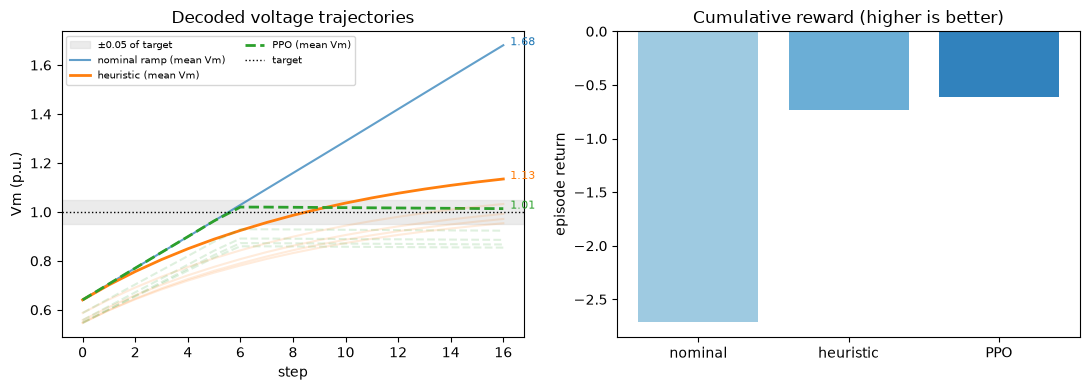

In [6]:
bus_idx = [0, 40, 80, 117]
steps = np.arange(nominal_vm.shape[0])
mean_nominal = nominal_vm.mean(axis=1)
mean_heur = heur_vm.mean(axis=1)
mean_ppo = ppo_vm.mean(axis=1) if ppo_vm is not None else None


def _traj_stats(name: str, mean_vm: np.ndarray, rewards: np.ndarray) -> None:
    print(
        f"{name}: return={rewards.sum():.4f}, "
        f"end mean Vm={mean_vm[-1]:.3f}, "
        f"episode-mean Vm={mean_vm.mean():.3f}"
    )


_traj_stats('nominal', mean_nominal, nominal_rewards)
_traj_stats('heuristic', mean_heur, heur_rewards)
if mean_ppo is not None and ppo_rewards is not None:
    _traj_stats('PPO', mean_ppo, ppo_rewards)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].axhspan(0.95, 1.05, color='0.85', alpha=0.5, label='±0.05 of target')
axes[0].plot(steps, mean_nominal, alpha=0.7, label='nominal ramp (mean Vm)')
axes[0].plot(steps, mean_heur, linewidth=2, label='heuristic (mean Vm)')
if mean_ppo is not None:
    axes[0].plot(steps, mean_ppo, linestyle='--', linewidth=2, label='PPO (mean Vm)')
for idx in bus_idx:
    axes[0].plot(steps, heur_vm[:, idx], alpha=0.15, color='C1')
    if ppo_vm is not None:
        axes[0].plot(steps, ppo_vm[:, idx], alpha=0.15, color='C2', linestyle='--')
axes[0].axhline(TARGET_VM, color='k', linestyle=':', linewidth=1, label='target')
# Annotate end mean Vm from the plotted arrays.
end_x = steps[-1]
axes[0].annotate(
    f'{mean_nominal[-1]:.2f}',
    xy=(end_x, mean_nominal[-1]),
    xytext=(5, 0),
    textcoords='offset points',
    fontsize=8,
    color='C0',
)
axes[0].annotate(
    f'{mean_heur[-1]:.2f}',
    xy=(end_x, mean_heur[-1]),
    xytext=(5, 0),
    textcoords='offset points',
    fontsize=8,
    color='C1',
)
if mean_ppo is not None:
    axes[0].annotate(
        f'{mean_ppo[-1]:.2f}',
        xy=(end_x, mean_ppo[-1]),
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=8,
        color='C2',
    )
axes[0].set_xlabel('step')
axes[0].set_ylabel('Vm (p.u.)')
axes[0].set_title('Decoded voltage trajectories')
axes[0].legend(fontsize=7, ncol=2)

labels = ['nominal', 'heuristic']
returns = [nominal_rewards.sum(), heur_rewards.sum()]
if ppo_rewards is not None:
    labels.append('PPO')
    returns.append(ppo_rewards.sum())
axes[1].bar(labels, returns, color=['#9ecae1', '#6baed6', '#3182bd'][: len(labels)])
axes[1].set_ylabel('episode return')
axes[1].set_title('Cumulative reward (higher is better)')

plt.tight_layout()
plt.show()


## Takeaways

**Results.** With the default (non-CI) hyperparameters, episode returns improve
monotonically: nominal ramp < heuristic < PPO (see the printed returns above).
PPO drives network-mean decoded $V_m$ into the $\pm 0.05$ band around 1.0 p.u.
by mid-episode and holds there through the end (see printed end mean Vm and
figure annotations). The heuristic improves on open-loop but still finishes
above the band; the nominal ramp overshoots well above 1.0. Higher $V_m$ is
not automatically better under the MSE-to-target reward.

**Scope.** These are closed-loop **latent** rollouts on a diffusion+ramp
surrogate, not comparisons to an AC power-flow IEEE 118 trajectory. The
notebook demonstrates the Gymnasium wrapper and control API, not grid-scale
optimality.

**Limitations.**

- **Frozen encoder/decoder:** RL only adjusts the applied control $u_t$; it does
  not correct representation error from the offline GNN lift.
- **Global control:** one scalar load-ramp input drives all buses; realistic
  voltage control often uses regional setpoints.
- **Action support:** closed-loop $u_t$ may leave the offline ramp range
  $[\approx 0.85, 1.15]$; interpret actions as latent controls, not generator
  setpoints.
- **Linear latent dynamics:** PPO optimizes over $z_{t+1} = K z_t + B u_t$;
  large disturbances may require online adaptation (`adapt_step`) or refitting.
- **Benchmark physics:** diffusion + ramp is a teaching surrogate, not a
  power-flow-accurate grid model.
